# ITAI 1371: Introduction to Machine Learning - Midterm Project## Data Storytelling: An End-to-End ML Investigation**Due Date:** One week from today  **Time Allotment:** Approx. 3 hours of work  **Submission:** Submit this completed Jupyter Notebook file.---### Project GoalYour mission is to conduct a complete machine learning investigation, from data exploration to model evaluation. More than just writing code, you will be a **data storyteller**. Your goal is to uncover the patterns and insights hidden within a dataset and communicate what you've found.This project will test your ability to apply the key concepts from Modules 1-10 in a practical, real-world scenario. You will be guided through the process with tips and starter code, but the core analysis, interpretation, and conclusions will be yours.### Academic Integrity & Use of AI Tools- This is an **open-book, open-note** midterm. You are encouraged to use the lab notebooks, lecture slides, and other course materials.- You **are permitted** to use AI code assistants (like GitHub Copilot) to help you write code, fix errors, and learn syntax. This is a valuable real-world skill.- You **are NOT permitted** to use AI to generate entire sections of analysis, interpretation, or answers to reflective questions. The goal is for *you* to demonstrate understanding.**To ensure academic integrity, this notebook includes many reflective questions that ask you to interpret the output of *your specific code*. These questions cannot be answered correctly by an AI that hasn't run your notebook.**---### Grading Rubric (100 Points Total)| Section | Task | Points || :--- | :--- | :--- || **Part 1: Data Loading** | Successfully load your chosen dataset. | 5 || **Part 2: EDA** | Create and interpret at least two relevant visualizations. | 20 || | Write a clear interpretation of the story your plots tell. | || **Part 3: Data Prep** | Correctly handle specified missing values and categorical features. | 15 || | Justify your choices in the markdown cells. | || **Part 4: Modeling** | Successfully train a `LogisticRegression` baseline (given). | 15 || | Successfully train a second model of your choice. | || **Part 5: Evaluation** | Calculate and compare accuracy for both models. | 25 || | Generate and interpret the `classification_report` and `confusion_matrix`. | || | Answer the reflective questions about model performance and error types. | || **Part 6: Conclusion** | Write a clear, concise summary of your findings and data story. | 15 || | Address the key questions in the conclusion prompt. | || **Overall** | Code is clean, commented, and runs without errors. All markdown cells are filled out. | 5 |

## Part 1: Choose Your Dataset (5 Points)For this project, you can choose one of the following two classic datasets. Both are classification problems.1.  **Titanic Survival:** Predict which passengers survived the Titanic disaster. (You are familiar with this from our lab).2.  **Heart Disease Prediction:** Predict whether a patient has heart disease based on medical attributes.**Instructions:**1.  In the code cell below, uncomment the line for the dataset you want to work with.2.  Run the cell to load the data into a pandas DataFrame called `df`.3.  Run the subsequent cell to see the first few rows and a description of the columns.

In [1]:
import pandas as pd
import numpy as np

# --- CHOOSE YOUR DATASET ---

# Option 1: Titanic Dataset
dataset_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"


# This code will load the dataset from the URL you selected above
try:
    df = pd.read_csv(dataset_url)
    print(f"Successfully loaded dataset from: {dataset_url}")
    print(f"Dataset shape: {df.shape}")
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Please make sure you have selected a valid URL.")

Successfully loaded dataset from: https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
Dataset shape: (891, 12)


### Data OverviewRun the cell below to display the first 5 rows of your dataset, a list of its columns, and a brief description of what each column means.

In [2]:
# Display the first 5 rows of the dataframe
print("--- First 5 Rows ---")
print(df.head())

# Display column info and descriptions
print("--- Column Descriptions ---")
if 'PassengerId' in df.columns:
    # Titanic Dataset
    print("You are using the Titanic Dataset.")
    print("Target Variable: 'Survived' (0 = No, 1 = Yes)")
    print("PassengerId: Unique passenger identifier")
    print("Pclass: Passenger class (1 = First, 2 = Second, 3 = Third)")
    print("Name: Passenger name")
    print("Sex: Passenger gender")
    print("Age: Passenger age in years")
    print("SibSp: Number of siblings/spouses aboard")
    print("Parch: Number of parents/children aboard")
    print("Ticket: Ticket number")
    print("Fare: Passenger fare")
    print("Cabin: Cabin number (many missing values)")
    print("Embarked: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)")
else:
    # Heart Disease Dataset
    print("You are using the Heart Disease Dataset.")
    print("Target Variable: 'target' (0 = No Heart Disease, 1 = Has Heart Disease)")

# A helper to rename columns for the heart disease dataset for clarity
if 'cp' in df.columns:
    df = df.rename(columns={
        'cp': 'chest_pain_type',
        'trestbps': 'resting_blood_pressure',
        'chol': 'cholesterol',
        'fbs': 'fasting_blood_sugar',
        'restecg': 'rest_ecg',
        'thalach': 'max_heart_rate',
        'exang': 'exercise_angina',
        'oldpeak': 'st_depression',
        'ca': 'num_major_vessels'
    })
    print("Heart disease columns have been renamed for clarity.")

print("--- Data Info ---")
df.info()

--- First 5 Rows ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.050

**bold text**## Part 2: Exploratory Data Analysis (EDA) & Storytelling (20 Points)Now, it's time to be a data detective. Before you can model the data, you must understand it. What secrets does it hold?**Your Task:**1.  **Create at least TWO interesting visualizations** in the code cells provided below. You can create more if you like.    *   Use libraries like `matplotlib` or `seaborn`.    *   Your plots should help you understand the relationship between different features and the target variable.    *   **Tip:** Think about the questions we asked during the Titanic lab (e.g., "How does survival rate differ by gender?" or "What is the age distribution of survivors?"). Ask similar questions of your dataset.2.  **Interpret your visualizations** in the markdown cell provided. Explain what you see and what story your plots are starting to tell.

### Visualization 1**Instructions:** Create your first plot in the cell below. Make sure to give it a title and label your axes! Good plots are easy to read.

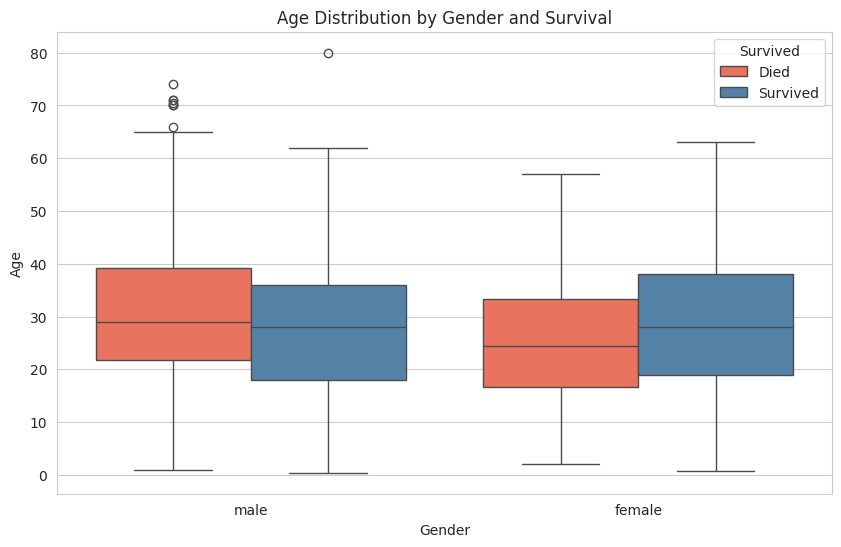

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Create a boxplot to compare age distributions by gender and survival status
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Sex",
    y="Age",
    hue="Survived",
    palette=["tomato", "steelblue"]
)

plt.title("Age Distribution by Gender and Survival")
plt.xlabel("Gender")
plt.ylabel("Age")

handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(
    handles=handles,
    labels=["Died", "Survived"],
    title="Survived"
)

plt.show()


### Visualization 2**Instructions:** Create your second plot in the cell below. Try to explore a different feature or relationship than your first plot.

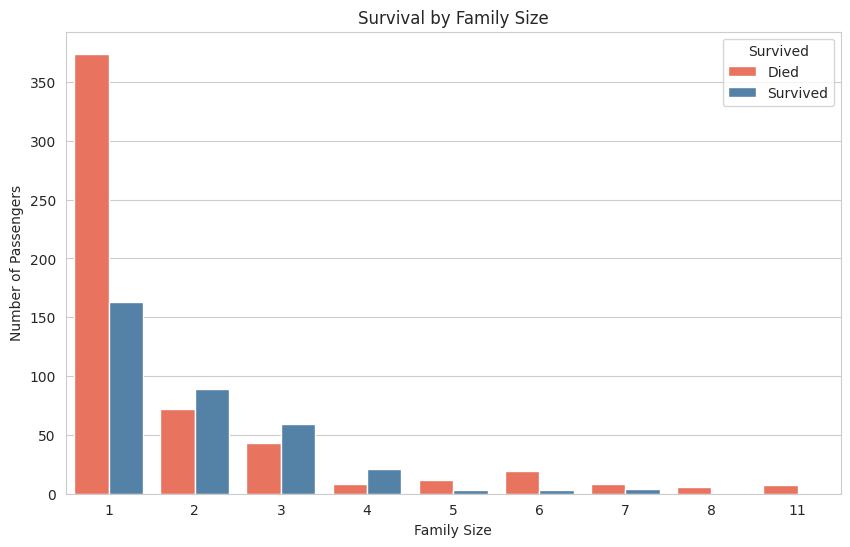

In [4]:
# Create a new feature representing the total family members aboard
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

plt.figure(figsize=(10, 6))

sns.countplot(
    x="FamilySize",
    hue="Survived",
    data=df,
    palette={
        0: "tomato",
        1: "steelblue"
    }
)

plt.title("Survival by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Number of Passengers")

handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ["Died", "Survived"], title="Survived")


plt.show()


### Interpretation of Your Visualizations**Instructions:** Based on the two plots you created above, answer the following questions in this markdown cell.1.  **What did you plot?** (Briefly describe your two visualizations).2.  **What story do your plots tell?** (What initial insights or patterns did you discover? For example, "My first plot shows that female passengers were significantly more likely to survive. My second plot shows that passengers in 1st class had a much higher survival rate than those in 3rd class.")3.  **What is one hypothesis you can form based on your EDA?** (e.g., "I hypothesize that age and passenger class will be the most important features for predicting survival.")

1. I created two visualizations to explore factors associated with passenger survival. The first is a boxplot comparing the age distributions of male and female passengers by survival status. The second is a countplot showing survival outcomes by 'Family Size', a newly engineered feature created by combining the number of siblings/spouses and parents/children traveling with each passenger.

2. Using these visualizations, I recognized several meaningful patterns. The age-by-gender boxplot suggests that female passengers survived at much higher rates across a broad range of ages, while adult males experienced appreciably lower survival rates. The succeedingFamily Size countplot indicates that passengers traveling alone or in smaller family groups generally had better survival outcomes than those in larger groups.

3. Based on these observations, I would suggest that gender, age, and family size would be among the most informative predictors of survival. These features display clear differences between survivors and non-survivors during exploratory data analysis, demonstrating they are some of hte most useful features for predicting survival outcomes when classification models are introduced.

## Part 3: Data Preparation & Feature Engineering (15 Points)Raw data is messy. We need to clean it up before feeding it to our models.**Your Task:**1.  **Handle Missing Values:** I've provided code to check for missing values. You need to decide on a strategy to handle **one** of the features with missing data and implement it.2.  **Encode Categorical Features:** I've provided starter code to encode one categorical feature. You need to encode **one more** categorical feature of your choice.3.  **Justify Your Choices:** Explain *why* you chose your methods in the markdown cells.

In [5]:
# Check for missing values
print("--- Missing Values Before ---")
print(df.isnull().sum())

# Fill missing Age values with the median (robust to outliers)
df["Age"] = df["Age"].fillna(df["Age"].median())

print("--- Missing Values After ---")
print(df.isnull().sum())

--- Missing Values Before ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
FamilySize       0
dtype: int64
--- Missing Values After ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
FamilySize       0
dtype: int64


**Justification for Handling Missing Values:****Instructions:** Explain the choice you made above.1.  **Which feature did you choose?**2.  **What method did you use to handle the missing values (e.g., fill with median, mode, or drop)?**3.  **Why was this an appropriate method for this feature?
1. Which feature did you choose?

    ***I chose the Age feature.***
2. What method did you use to handle the missing values?

    ***I filled the missing values in the Age column using the median of the existing values.***
3. Why was this an appropriate method for this feature?

   ***From a domain perspective (history), Age is an meaningful predictor of survival because historically children were often prioritized for evacuation (and therefore survival). From a statistical point of view, the Age feature is numerical and contains a moderate number of missing values (177 entries). In light of best practices, using the median is appropriate because it is resilient to outliers and prevents extreme values from skewing the distribution, as we learned in module 04.  Moreover, using the median also allowed me to retain all passenger records instead of dropping nearly 20% of the dataset due to missing values (missing values in age / total passengers in dataset). Although imputing median vlaues cannot reclaim each passenger's passenger's true age , it provides a better statistical estimate than mean, and preserves the dataset for model training.***

In [6]:
# --- Encoding: Sex ---

if 'Sex' in df.columns:
    df['sex_encoded'] = df['Sex'].map({'female': 0, 'male': 1})

print("--- Encoding Example: Sex ---")
print(df[['Sex', 'sex_encoded']].head())


# --- ENncodeing: Embarked ---

# Encode 'Embarked' using one-hot encoding
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# --- END OF YOUR CODE ---

print("--- Dataframe after your encoding ---")
print(df.head())

--- Encoding Example: Sex ---
      Sex  sex_encoded
0    male            1
1  female            0
2  female            0
3  female            0
4    male            1
--- Dataframe after your encoding ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin  FamilySize  sex_encoded  \
0      0         A/5 21171   7.2500   NaN   

**Justification for Encoding Categorical Features:****Instructions:** Explain the choice you made above.1.  **Which feature did you choose to encode?**2.  **What encoding method did you use (e.g., map, pd.get_dummies)?**3.  **Why was this the right method? If you used `get_dummies`, why is `drop_first=True` often a good idea?****-

1. Which feature did you choose to encode?

    ***I encoded the Sex and Embarked features because both are categorical variables that contain important information about passenger survival.***
2. What encoding method did you use (e.g., map, pd.get_dummies)?

    ***I used the .map() method to convert the binary categorical Sex feature into numerical values (female = 0, male = 1). For the Embarked feature, which contains three categories, I used pd.get_dummies() with drop_first=True to create one-hot encoded variables.***

3. Why was this the right method? If you used get_dummies, why is drop_first=True often a good idea?

    ***These two abovementioned methods were suitable because they essentially convert categorical variables into a numerical format that math-based machine learning models can understand. The Sex feature is binary, so mapping it to 0 and 1 is preserves the simplicity of the feature's variable. The Embarked feature contains three distinct, nominal categories representing passengers' ports of departure. One-hot encoding creates a separate binary feature for each category, allowing the model to evaluate each port of embarkment independently. Using DROP_FIRST=TRUE during one-hot codding prevents what is known as "multicollinearity" by removing one redundant column, since the remaining emarkment columns implicitly represent all categories by default.***

## Part 4 & 5: Modeling and Evaluation (40 Points)Now for the main event! Let's train some models and see how well they can predict outcomes.**Your Task:**1.  **Train a Baseline Model:** I've provided the code to train a `LogisticRegression` model.2.  **Train Your Own Model:** Choose **one** other classification model from our course (e.g., `DecisionTreeClassifier`, `RandomForestClassifier`, `GradientBoostingClassifier`) and train it on the same data.3.  **Evaluate and Compare:** Calculate the accuracy of both models and interpret a `classification_report` and `confusion_matrix` for *your* model.4.  **Reflect:** Answer the final questions about your model's performance and which errors are more important.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# --- Define Features (X) and Target (y) ---

df_model = df.copy()

# Keep only numeric columns (after encoding, this is safe)
df_model = df_model.select_dtypes(include=np.number)

# Drop PassengerId if present (not useful for prediction)
if 'PassengerId' in df_model.columns:
    df_model = df_model.drop(columns=['PassengerId'])

# Ensure no missing values remain
df_model = df_model.dropna()

# Define target variable
target_col = 'Survived' if 'Survived' in df_model.columns else 'target'

X = df_model.drop(target_col, axis=1)
y = df_model[target_col]

# --- Split Data ---

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Training set has {X_train.shape[0]} samples.")
print(f"Test set has {X_test.shape[0]} samples.")
print(f"Features used: {X.columns.tolist()}")

Training set has 712 samples.
Test set has 179 samples.
Features used: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'sex_encoded']


### Model 1: Logistic Regression (Baseline)This model is provided for you as a

1.   List item
2.   List item

baseline to compare against.

In [8]:
# Train the baseline model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Make predictions and evaluate
y_pred_log_reg = log_reg.predict(X_test)

acc_log_reg = accuracy_score(y_test, y_pred_log_reg)

print(f"Baseline Model (Logistic Regression) Test Accuracy: {acc_log_reg:.2%}")

Baseline Model (Logistic Regression) Test Accuracy: 81.01%


### Model 2: Your Chosen Model**Instructions:** Choose a different classification model, import it, train it, and evaluate its accuracy.

In [9]:
from sklearn.ensemble import HistGradientBoostingClassifier
"""
MODEL COMPARISON SUMMARY:

We evaluated multiple classification models on the Titanic dataset:

- Logistic Regression: ~81.01%
- Random Forest: ~81.01%
- Gradient Boosting: ~80.45%
- Decision Tree: ~76.54%
- HistGradientBoosting: ~82.12% (best)

HistGradientBoosting achieved the highest accuracy, but the improvement (~1%) over simpler models is small.
This suggests the dataset has strong predictive signals that are already captured well by simpler models,
and that performance differences are likely due to minor variability rather than meaningful gains.

Overall, results show that increasing model complexity does not always lead to significantly better performance on this dataset.
"""
# 1. Create model instance
my_model = HistGradientBoostingClassifier(
    random_state=42
)

# 2. Train model
my_model.fit(X_train, y_train)

# 3. Make predictions
y_pred_my_model = my_model.predict(X_test)

# 4. Evaluate accuracy
acc_my_model = accuracy_score(y_test, y_pred_my_model)

print(f"HistGradientBoosting Model Test Accuracy: {acc_my_model:.2%}")



HistGradientBoosting Model Test Accuracy: 82.12%


### Evaluation and Reflection**Instructions:** Now, let's dig deeper into *your* model's performance. Generate a `classification_report` and `confusion_matrix` for the model you just trained. Then, answer the reflective questions.

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       105
           1       0.79      0.77      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

--- Confusion Matrix ---
[[90 15]
 [17 57]]


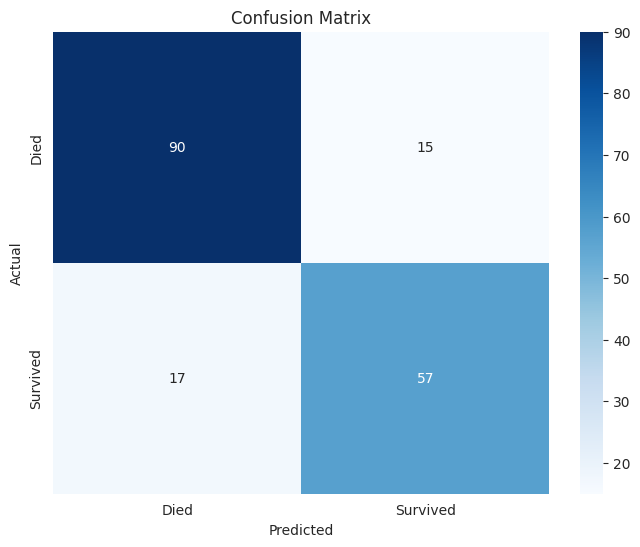

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate and print classification report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred_my_model))

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_my_model)

print("--- Confusion Matrix ---")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

labels = ["Died", "Survived"]

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

**Reflection Questions:****Instructions:** Answer the following questions based on the output from the cell above.1.  **Which model performed better, the baseline or yours?** Was it a big difference?2.  **Look at the `classification_report` for your model. What are the precision and recall for the positive class (1)?** (Just state the values).3.  **Interpret the precision and recall. In the context of your chosen dataset, what do these numbers mean?** (e.g., "A recall of 0.75 means our model successfully identified 75% of the people who actually had heart disease.")4.  **Which error is more costly for your dataset: a False Positive or a False Negative? Explain your reasoning.** (There is no single right answer, it depends on your justification).    *   **Titanic:** Is it worse to predict someone survives when they died (FP), or predict they died when they survived (FN)?    *   **Heart Disease:** Is it worse to tell a healthy person they have heart disease (FP), or tell a sick person they are healthy (FN)?

1.
    **The HistGradientBoosting model performed slightly better than the baseline Logistic Regression model, achieving an accuracy of 82.12% compared with 81.01%. Although the gradient boosting model produced the best overall performance, the improvement was only about 1.1 percentage points. Such little marked improvement between the baseline and custom selected model seems to suggest that increasing model capability sometimes yields only modest gains.A competent AI/ML developer avoids a fixation on accuracy alone, and instead focuses on bestcapturing predictive patterns in a dataset, irrespective of model choice.**

2. For the positive class (1 = Survived):
   
   * Precision: 0.79
   * Recall: 0.77

3.
    ***A precision of 0.79 means that when the model predicts a passenger survived, it is correct 79% of the time. A recall of 0.77 means the model successfully identifies 77% of all actual survivors, while approximately 23% of survivors are missed. The confusion matrix reinforces this analysis, as it shows that the model correctly identified 57 survivors but failed to recognize 17 actual survivors. The slightly lower recall indicates that the custom model misses a small portion of survivors, which in turn suggests that the custom model is fairly conservative in predicting survival outcomes.  These metrics illustrate the tradeoff between precision and recall. Increasing recall would likely identify more true survivors but could also increase the number of incorrect survival predictions (false positives). Conversely, increasing precision would reduce false positives but might miss additional survivors.***

4.
    ***A False Negative is more costly in this context because it occurs when the model predicts that a passenger did not survive, but in reality, they did survive. This is particularly problematic because it means the model incorrectly assumes a survivor is dead, leading to missed opportunities to identify or prioritize individuals who are actually alive. In a real-world rescue scenario, this could result in someone not receiving timely assistance or being deprioritized during search and rescue efforts.***

    ***In contrast, a False Positive (predicting survival when the passenger actually died) is generally less severe in this context, as it reflects an overestimation of survival rather than failing to identify actual survivors.Since prioritizing the identification of actual survivors is the more appropriate choice, a false negative is potentially more costly for the Titanic dataset.***






## Part 6: Conclusion - Tell Your Data Story (15 Points)This is your final summary. Bring together everything you've learned from your investigation.**Instructions:**Write 2-3 paragraphs summarizing your project. Your summary should be a narrative that tells the story of your data. Address the following points:-   **What was the main goal of your project?**-   **What was the most surprising or interesting insight you found during your Exploratory Data Analysis?**-   **Which features seemed to be the most important for making predictions?**-   **How well did your best model perform, and what are its limitations?** (Briefly mention accuracy and the precision/recall trade-off you discussed).-   **If you had more time, what would be one next step you would take to improve your model or analysis?

***The main goal of this project was to conduct an end-to-end machine learning investigation. To that end, I built an ML pipeline to predict passenger survival on the Titanic dataset, moving from raw data exploration through preprocessing, modeling, and evaluation. The primary objective was not solely achieving good predictive performance; rather, the goal was to explore AND story-tell the data, capture meaningful features, and evaluate how well different classification models could learn patterns from real-world historical data.***

***During this ML lab, I used exploratory data analysis (EDA) to recognize interesting insights in the Titanic dataet. For example, in terms of survival, the data output demonstrated the strong impact of gender and group structure on survival. Female passengers were significantly more likely to survive across almost all age ranges, reinforcing the historical “women and children first” evacuation pattern. Moreover, passengers traveling in smaller family groups (or alone) held higher survival rates compared to those in larger family groups, suggesting that group size may have negatively affected the collective ability to evacuate efficiently. These observed patterns indicated that key features such as Sex, Age, and even Family Size were examples of important predictors to hone in on as I moved toward the modeling phase.***

***In terms of accuracy and predictive performance, the best model (HistGradientBoostingClassifier) achieved an accuracy of 82.12%, slightly outperforming Logistic Regression at 81.01%. However, the improvement was marginal, demonstrating that both models captured most of the meaningful signal in the dataset. The classification report showed a trade-off between precision and recall for the survival class (precision ≈ 0.79, recall ≈ 0.77), meaning the model was fairly balanced but still missed a portion of actual survivors.***

***If I had more time, a key next step would be to use cross-validation and hyperparameter tuning to better evaluate model stability and perhaps reduce dependence on a single train-test split, as we explored in other modules. This would provide a more reliable estimate of how well the model generalizes beyond this dataset. I would also expand the feature engineering beyond Family Size by exploring additional information already available in the dataset. For example, Pclass and Fare could be combined to better capture socioeconomic status, which may be more predictive of survival than either feature alone.***

## 🎉 You've reached the end of the midterm project! 🎉**Before you submit:**1.  Go to the `Kernel` menu and select `Restart & Run All`. This will run all your cells from top to bottom.2.  Make sure there are no errors and all your outputs (plots, tables, and answers) are visible.3.  Save the notebook file (`.ipynb`).4.  Submit the file as your midterm.**Great work!**